# CISA SBOM Thematic & Normative Analysis Notebook

This notebook conducts a comprehensive analysis of the normative requirements extracted from the CISA "Framing Software Component Transparency, Third Edition" document. The analysis is divided into two main parts:

1.  **Thematic Analysis:** This section visualizes the hierarchical structure of themes and subthemes derived from the open coding process, helping to understand the primary areas of focus within the specification.
2.  **Normative Keyword Analysis:** This section analyzes the frequency and distribution of RFC 2119 keywords (e.g., REQUIRED, SHOULD, MAY) to quantify the strictness of the requirements across different themes.

The findings from this notebook will serve as a foundation for developing a comprehensive test suite for SBOM generation tools.

**Input File:** `cisa_coding.csv`

In [12]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for the plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load the dataset from the CSV file
try:
    df = pd.read_csv('cisa_coding.csv')
    print("Dataset loaded successfully.")
    print(f"Total requirements found: {len(df)}")
except FileNotFoundError:
    print("Error: 'cisa_coding.csv' not found. Please ensure the file is in the same directory as this notebook.")

# Display the first few rows to verify the data
df.head()

Dataset loaded successfully.
Total requirements found: 133


,Section ID & Heading,Recommendation / Requirement,Normative Keyword,Code,Rationale/Context,Subtheme,Theme
0,1.1 Goals,Declaring a required minimum set of Baseline A...,REQUIRED,Defining Baseline Attributes,Minimum attributes needed for unique component...,Foundational Principles,Foundational Principles
1,1.1 Goals,"identifying supplemental, optional Attributes ...",OPTIONAL,Supporting Supplemental Attributes,Optional attributes can support diverse use cases,Foundational Principles,Foundational Principles
2,2 What is an SBOM?,An SBOM’s inventory should be as comprehensive...,SHOULD,Ensuring Inventory Comprehensiveness,NaN,Foundational Principles,Foundational Principles
3,2 What is an SBOM?,An SBOM’s inventory should explicitly state wh...,SHOULD,Declaring Relationship Gaps,NaN,Data Completeness & Transparency,Data Governance & Transparency
4,2 What is an SBOM?,a machine-readable format is critical to suppo...,REQUIRED,Mandating Machine-Readable Formats,NaN,Format & Interoperability,Foundational Principles


## 2. Data Cleaning and Preparation

Before analysis, we perform a few preparatory steps:
- Inspect the data for any missing values.
- Standardize the normative keywords to group similar terms (e.g., `MUST` becomes `REQUIRED`) for consistent analysis.

In [13]:
# Check for missing values in key columns
print("Missing values per column:")
print(df[['Theme', 'Subtheme', 'Normative Keyword']].isnull().sum())

# Standardize the normative keywords for consistent counting
# Create a mapping for similar keywords
keyword_map = {
    'MUST': 'REQUIRED',
    'RECOMMENDED': 'SHOULD',
    'OPTIONAL': 'MAY'
}

# Apply the mapping to a new column called 'Standard_Keyword'
df['Standard_Keyword'] = df['Normative Keyword'].replace(keyword_map)

# Verify the standardized keyword counts
print("\nStandardized Normative Keyword Counts:")
print(df['Standard_Keyword'].value_counts())

Missing values per column:
Theme                0
Subtheme             0
Normative Keyword    0
dtype: int64

Standardized Normative Keyword Counts:
Standard_Keyword
REQUIRED    57
SHOULD      49
MAY         27
Name: count, dtype: int64


## 3. Thematic Analysis: Hierarchy and Frequency

This section visualizes the results of our thematic analysis. We will first display the complete hierarchy of themes and subthemes and then create charts to show the frequency of their occurrence, highlighting the specification's main areas of focus.

### 3.1. Theme and Subtheme Hierarchy (Text-based Tree)

The following output shows the final, structured taxonomy of the CISA SBOM requirements.

In [14]:
# Group by Theme and Subtheme to extract the hierarchy
hierarchy = df.groupby('Theme')['Subtheme'].unique().to_dict()

print("--- CISA SBOM Thematic Hierarchy ---")
for theme, subthemes in hierarchy.items():
    print(f"\nTheme: {theme}")
    for subtheme in subthemes:
        print(f"  └── Subtheme: {subtheme}")
print("\n------------------------------------")

--- CISA SBOM Thematic Hierarchy ---

Theme: Component & SBOM Attributes
  └── Subtheme: Component Identification
  └── Subtheme: SBOM Metadata
  └── Subtheme: Cryptographic Hashes
  └── Subtheme: Unique Identifiers
  └── Subtheme: Legal Information

Theme: Data Governance & Transparency
  └── Subtheme: Data Completeness & Transparency
  └── Subtheme: Handling Redactions

Theme: Foundational Principles
  └── Subtheme: Foundational Principles
  └── Subtheme: Format & Interoperability

Theme: SBOM Operations & Lifecycle
  └── Subtheme: Lifecycle Management
  └── Subtheme: Supply Chain Practices
  └── Subtheme: SBOM Creation & Tooling
  └── Subtheme: Assurance & Trust
  └── Subtheme: SBOM Distribution

Theme: Supply Chain Relationships
  └── Subtheme: Dependency & Relationship Mapping

Theme: Use Case Enablement
  └── Subtheme: Use Case Enablement

------------------------------------


### 3.2. Theme Frequency Visualization

This bar chart shows the total number of requirements associated with each of the six major themes. This provides a high-level overview of the document's priorities.

/var/folders/57/74dt5t8x1374282qhg4yr_b80000gn/T/ipykernel_25906/2010823392.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




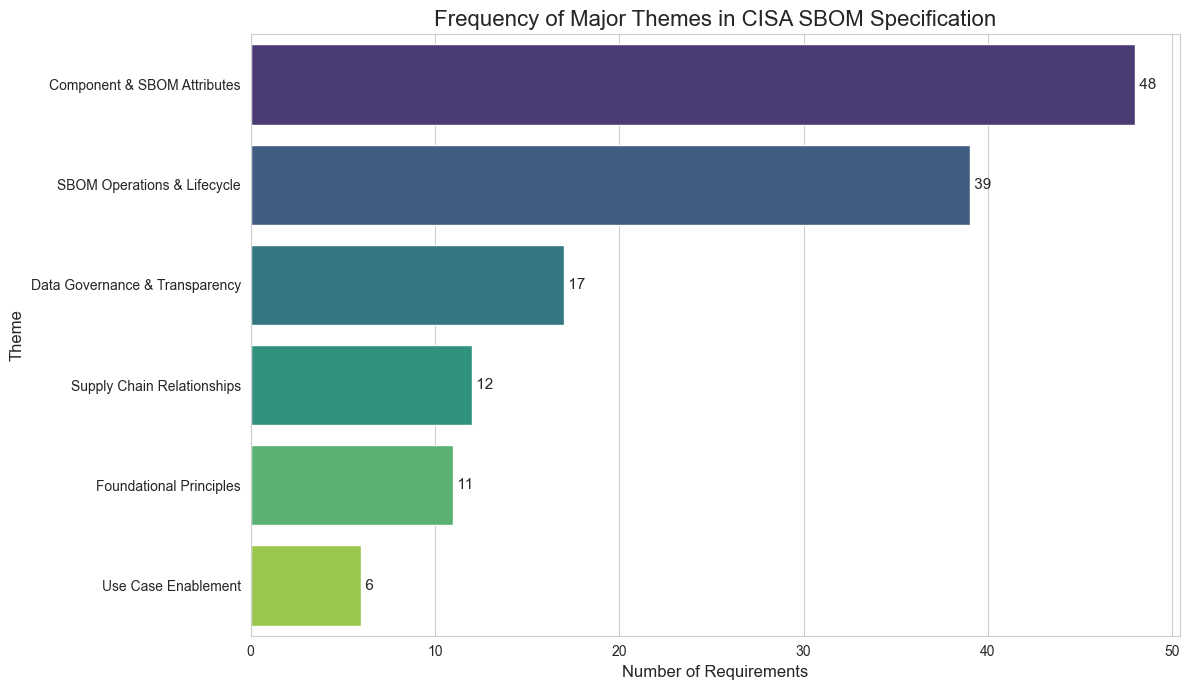

In [15]:
# Calculate the frequency of each major theme
theme_counts = df['Theme'].value_counts()

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x=theme_counts.values, y=theme_counts.index, palette='viridis', orient='h')

# Add labels and title for clarity
plt.xlabel('Number of Requirements', fontsize=12)
plt.ylabel('Theme', fontsize=12)
plt.title('Frequency of Major Themes in CISA SBOM Specification', fontsize=16)

# Add the count labels to the bars
for index, value in enumerate(theme_counts.values):
    plt.text(value, index, f' {value}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

### 3.3. Subtheme Frequency Visualization (Hierarchical)

This chart breaks down the analysis further, showing the frequency of each subtheme, grouped and colored by its parent theme. This reveals where the specification provides the most granular guidance.

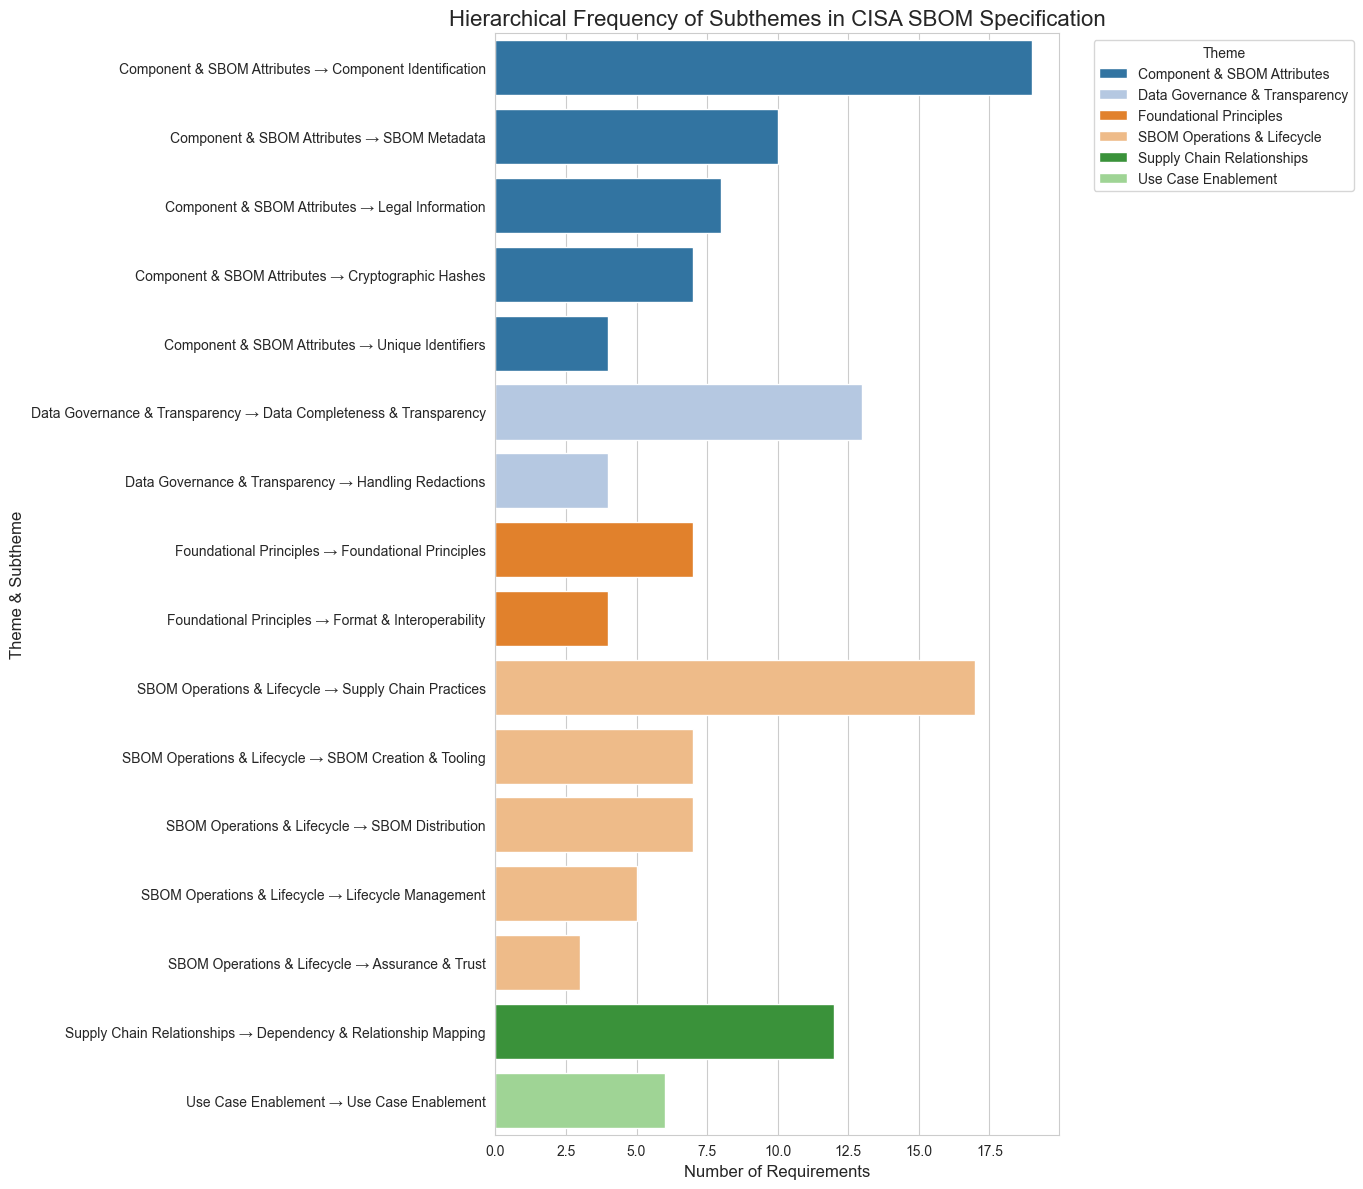

In [16]:
# Calculate the frequency of each subtheme
subtheme_counts = df.groupby(['Theme', 'Subtheme']).size().reset_index(name='Count')

# Sort the data for a cleaner, more organized plot
sorted_subthemes = subtheme_counts.sort_values(by=['Theme', 'Count'], ascending=[True, False])

# Create a combined label for the y-axis (convert to string to handle any NaN values)
sorted_subthemes['Hierarchical_Label'] = sorted_subthemes['Theme'].astype(str) + ' → ' + sorted_subthemes['Subtheme'].astype(str)

# Create the horizontal bar plot
plt.figure(figsize=(14, 12))
sns.barplot(x='Count', y='Hierarchical_Label', data=sorted_subthemes, hue='Theme', dodge=False, palette='tab20')

# Add labels and title
plt.xlabel('Number of Requirements', fontsize=12)
plt.ylabel('Theme & Subtheme', fontsize=12)
plt.title('Hierarchical Frequency of Subthemes in CISA SBOM Specification', fontsize=16)
plt.legend(title='Theme', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. Normative Keyword Analysis

This section analyzes the use of RFC 2119 keywords (`REQUIRED`, `SHOULD`, `MAY`) to understand the strictness and flexibility of the CISA guidelines. This analysis is crucial for prioritizing test cases.

### 4.1. Overall Frequency of Normative Keywords

This chart shows the overall count of each standardized keyword category, indicating the general tone of the document.

/var/folders/57/74dt5t8x1374282qhg4yr_b80000gn/T/ipykernel_25906/4117169779.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




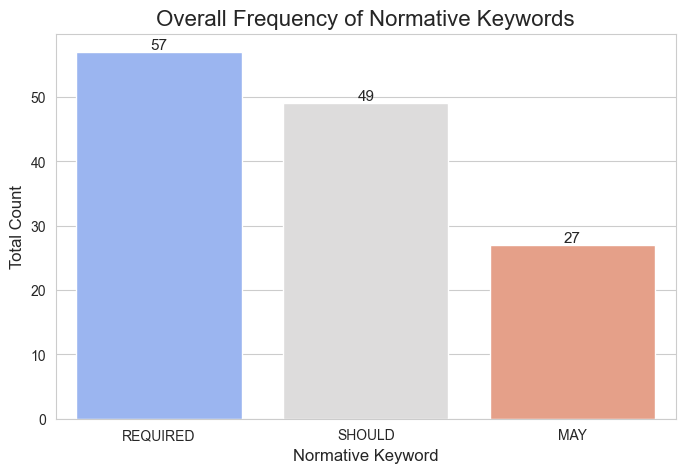

In [17]:
# Get the counts of the standardized keywords
keyword_counts = df['Standard_Keyword'].value_counts()

# Define a specific order for the keywords
keyword_order = ['REQUIRED', 'SHOULD', 'MAY']
keyword_counts = keyword_counts.reindex(keyword_order)

# Create the bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=keyword_counts.index, y=keyword_counts.values, palette='coolwarm')

# Add labels and title
plt.xlabel('Normative Keyword', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.title('Overall Frequency of Normative Keywords', fontsize=16)

# Add count labels
for i, count in enumerate(keyword_counts.values):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=11)

plt.show()

### 4.2. Keyword Distribution Across Themes

This is the most insightful visualization. The stacked bar chart below shows the *proportion* of `REQUIRED`, `SHOULD`, and `MAY` statements within each major theme. This allows us to see which areas of the specification are most strictly enforced. For example, are data fields more strictly defined than lifecycle processes?

Checking data before cross-tabulation...
Unique themes: ['Foundational Principles' 'Data Governance & Transparency'
 'Component & SBOM Attributes' 'Use Case Enablement'
 'Supply Chain Relationships' 'SBOM Operations & Lifecycle']
Unique standard keywords: ['REQUIRED' 'MAY' 'SHOULD']
Missing values in Theme: 0
Missing values in Standard_Keyword: 0
Rows after removing missing values: 133 (original: 133)
Distribution shape: (6, 3)
Distribution preview:
Standard_Keyword                MAY  REQUIRED  SHOULD
Theme                                                
Component & SBOM Attributes      10        13      25
Data Governance & Transparency    5         5       7
Foundational Principles           1         6       4
SBOM Operations & Lifecycle       7        23       9
Supply Chain Relationships        2         7       3
Use Case Enablement               2         3       1


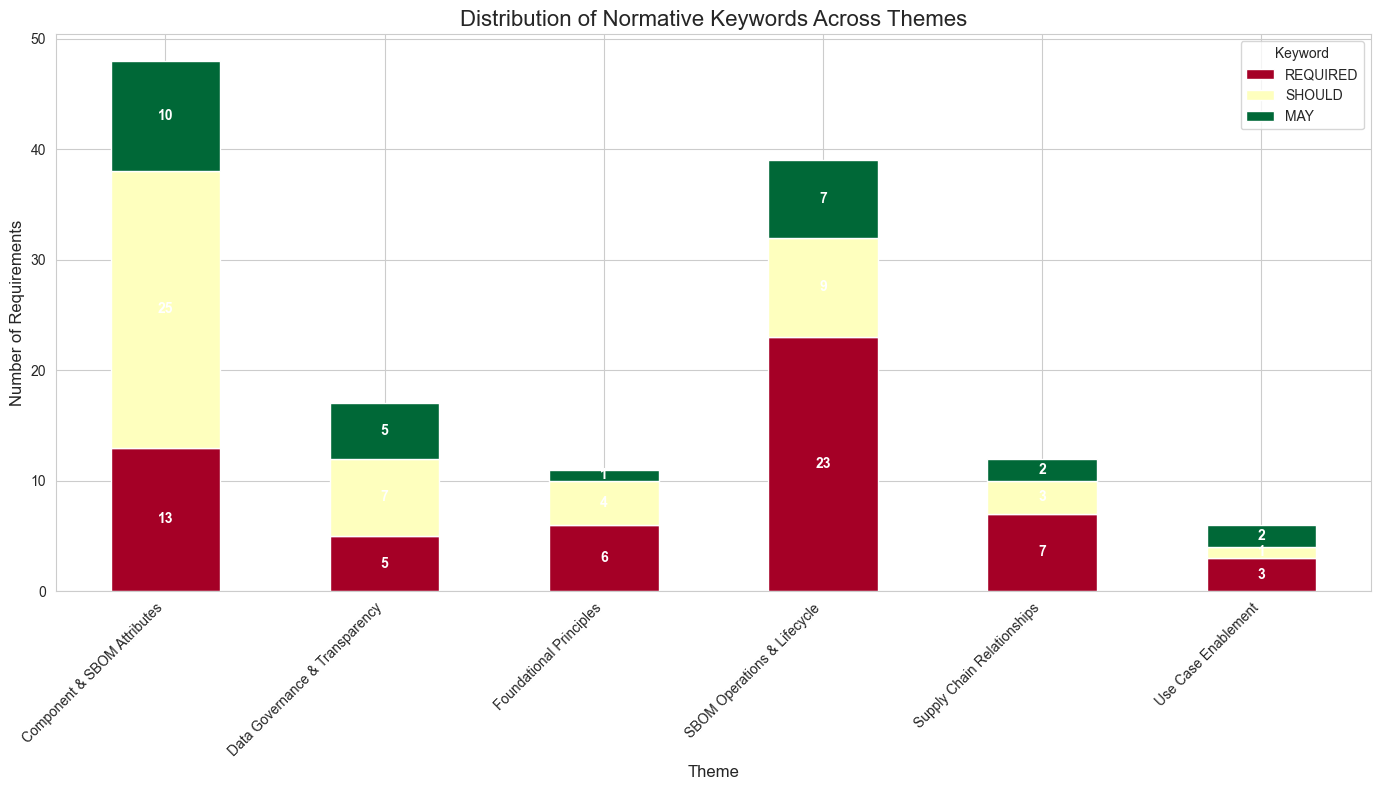

In [18]:
# First, let's check what data we have for the cross-tabulation
print("Checking data before cross-tabulation...")
print(f"Unique themes: {df['Theme'].unique()}")
print(f"Unique standard keywords: {df['Standard_Keyword'].unique()}")
print(f"Missing values in Theme: {df['Theme'].isnull().sum()}")
print(f"Missing values in Standard_Keyword: {df['Standard_Keyword'].isnull().sum()}")

# Remove any rows with missing values in the key columns
df_clean = df.dropna(subset=['Theme', 'Standard_Keyword'])
print(f"Rows after removing missing values: {len(df_clean)} (original: {len(df)})")

# Create a cross-tabulation of themes and standardized keywords
distribution = pd.crosstab(df_clean['Theme'], df_clean['Standard_Keyword'])

print(f"Distribution shape: {distribution.shape}")
print("Distribution preview:")
print(distribution)

# Check if we have any data to plot
if distribution.empty:
    print("No data available for plotting. Check your data cleaning steps.")
else:
    # Ensure the columns are in the desired order of strictness
    keyword_order = ['REQUIRED', 'SHOULD', 'MAY']
    # Only reindex with keywords that actually exist in the data
    available_keywords = [kw for kw in keyword_order if kw in distribution.columns]
    distribution = distribution.reindex(columns=available_keywords).fillna(0)
    
    # Create the stacked bar plot
    ax = distribution.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='RdYlGn')
    
    # Add labels and title
    plt.xlabel('Theme', fontsize=12)
    plt.ylabel('Number of Requirements', fontsize=12)
    plt.title('Distribution of Normative Keywords Across Themes', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Keyword')
    
    # Add count labels to each segment of the stacked bars
    for c in ax.containers:
        # customize the label to avoid showing 0
        labels = [int(v.get_height()) if v.get_height() > 0 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')
    
    plt.tight_layout()
    plt.show()

## 5. Hierarchical Visualizations of the Thematic Structure
To present the full taxonomy in a clear, visual format, we will generate two types of hierarchical graphs:
1. A Tree Diagram: To show the structural relationship between themes, subthemes, and individual codes.
2. An Interactive Treemap: To show both the structure and the frequency (i.e., importance) of each category.



### 5.1. Structural Tree Diagram (Graphviz)

This diagram visualizes the taxonomy as a classic tree, branching from themes to subthemes. This is ideal for showing the logical organization of the CISA requirements.

**Note:** This requires the `graphviz` library. You may need to install it first (`pip install graphviz`) and also install the Graphviz system software (e.g., `brew install graphviz` on macOS, or `sudo apt-get install graphviz` on Debian/Ubuntu).

Tree diagram saved as 'cisa_taxonomy_tree.png'


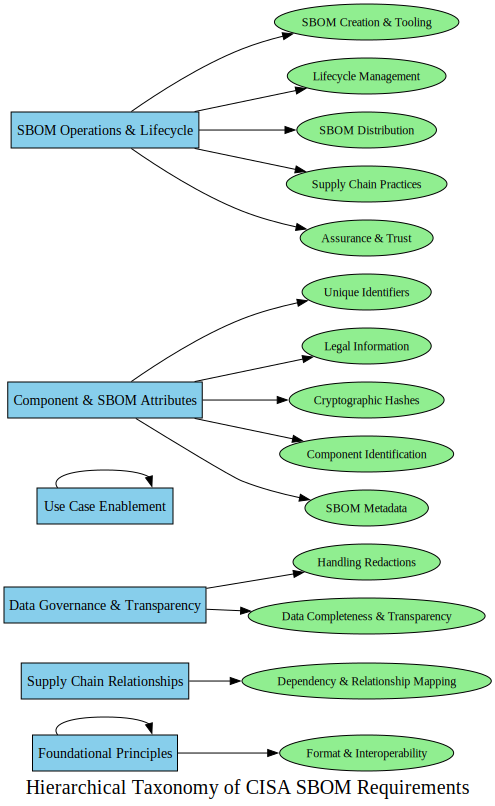

In [19]:
import graphviz

# Create a new directed graph
dot = graphviz.Digraph('CISA_SBOM_Taxonomy', comment='Thematic Hierarchy')
dot.attr(rankdir='LR', size='12,12', label='Hierarchical Taxonomy of CISA SBOM Requirements', fontsize='20')

# --- Create Nodes for Themes and Subthemes ---
# Use sets to avoid creating duplicate nodes
themes = set(df['Theme'])
subthemes = set(df['Subtheme'])

# Add Theme nodes (larger, different shape)
dot.attr('node', shape='box', style='filled', fillcolor='skyblue', fontsize='14')
for theme in themes:
    dot.node(theme, theme)

# Add Subtheme nodes (smaller)
dot.attr('node', shape='ellipse', style='filled', fillcolor='lightgreen', fontsize='12')
for subtheme in subthemes:
    dot.node(subtheme, subtheme)

# --- Create Edges to Connect the Hierarchy ---
# Connect Themes to their Subthemes
theme_subtheme_pairs = df[['Theme', 'Subtheme']].drop_duplicates()
for index, row in theme_subtheme_pairs.iterrows():
    dot.edge(row['Theme'], row['Subtheme'])
    
# --- (Optional) Add Leaf Nodes for Individual Codes ---
# This can make the graph very large, but is great for detailed views.
# You can uncomment this section to generate the full graph with leaves.
# dot.attr('node', shape='plaintext', fontsize='10')
# for index, row in df.iterrows():
#     # Create a unique ID for each code leaf to avoid node name clashes
#     code_id = f"code_{index}"
#     dot.node(code_id, row['Codes'])
#     dot.edge(row['Subtheme'], code_id)

# Render the graph and display it in the notebook
dot.render('cisa_taxonomy_tree', format='png', view=False)
print("Tree diagram saved as 'cisa_taxonomy_tree.png'")
dot

### 5.2. Interactive Treemap Visualization (Plotly)

A treemap is a powerful way to show hierarchy and magnitude simultaneously. The area of each rectangle is proportional to the number of requirements in that category. This makes it easy to see which themes and subthemes are most prominent in the CISA document.

**Note:** You can hover over any section to see its name and count. You can also click on a theme to "zoom in" and see its subthemes.

In [20]:
import plotly.express as px

# We need to count the occurrences to size the rectangles, but Plotly can do this automatically.
# However, for clarity, we can pre-calculate if needed. Here we let Plotly handle it.

# Create the treemap
# The 'path' argument defines the hierarchy from parent to child.
fig = px.treemap(df, 
                 path=[px.Constant("All Requirements"), 'Theme', 'Subtheme'], # Root -> Theme -> Subtheme
                 title='Hierarchical Distribution of CISA SBOM Requirements',
                 color_discrete_sequence=px.colors.qualitative.Prism)

# Update the layout for better readability
fig.update_layout(
    margin = dict(t=50, l=25, r=25, b=25),
    font=dict(size=14)
)

fig.update_traces(textinfo="label+value", hoverinfo="label+percent parent+value")


fig.show()